In [4]:
import pandas as pd
import numpy as np
pd.set_option("display.max_columns", None)  #To displa all full columns
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings   #To ignore warning sign
warnings.filterwarnings("ignore")  #To ignore warning sign
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler


In [5]:
df=pd.read_csv(r"C:\Users\MSI\Downloads\default of credit card clients sk.csv")

In [6]:
df.head()

,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
1,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
2,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0


In [7]:
# Dataset info
df.info()

# Check missing values
df.isnull().sum()

df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30001 entries, 0 to 30000
Data columns (total 25 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  30001 non-null  object
 1   X1          30001 non-null  object
 2   X2          30001 non-null  object
 3   X3          30001 non-null  object
 4   X4          30001 non-null  object
 5   X5          30001 non-null  object
 6   X6          30001 non-null  object
 7   X7          30001 non-null  object
 8   X8          30001 non-null  object
 9   X9          30001 non-null  object
 10  X10         30001 non-null  object
 11  X11         30001 non-null  object
 12  X12         30001 non-null  object
 13  X13         30001 non-null  object
 14  X14         30001 non-null  object
 15  X15         30001 non-null  object
 16  X16         30001 non-null  object
 17  X17         30001 non-null  object
 18  X18         30001 non-null  object
 19  X19         30001 non-null  object
 20  X20   

Index(['Unnamed: 0', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9',
       'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19',
       'X20', 'X21', 'X22', 'X23', 'Y'],
      dtype='object')

In [8]:
df.shape

(30001, 25)

In [9]:
df.describe()

,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
count,30001,30001,30001,30001,30001,30001,30001,30001,30001,30001,30001,30001,30001,30001,30001,30001,30001,30001,30001,30001,30001,30001,30001,30001,30001
unique,30001,82,3,8,5,57,12,12,12,12,11,11,22724,22347,22027,21549,21011,20605,7944,7900,7519,6938,6898,6940,3
top,ID,50000,2,2,2,29,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
freq,1,3365,18112,14030,15964,1605,14737,15730,15764,16455,16947,16286,2008,2506,2870,3195,3506,4020,5249,5396,5968,6408,6703,7173,23364


In [10]:
df.columns=df.iloc[0]

In [11]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object', name=0)

In [12]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
1,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
2,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.rename(columns={'default payment next month': 'default'}, inplace=True)

In [15]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
1,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
2,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0


In [16]:
df["default"].value_counts()

default
0                             23364
1                              6636
default payment next month        1
Name: count, dtype: int64

In [17]:
# Check missing values
df.isnull().sum()

# to handle any missing values,
df = df.dropna()  # to remove na


In [18]:
df.isnull().sum()

0
ID           0
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
default      0
dtype: int64

In [19]:
# Gender mapping
df['SEX'] = df['SEX'].map({1:'Male', 2:'Female'})

# Education mapping (fix anomalies)
C = df['EDUCATION'].replace({0:4, 5:4, 6:4})  # group into 'Others'

# Marital status mapping
df['MARRIAGE'] = df['MARRIAGE'].replace({0:3})  # group into 'Others'


In [20]:
df["SEX"]

0        NaN
1        NaN
2        NaN
3        NaN
4        NaN
        ... 
29996    NaN
29997    NaN
29998    NaN
29999    NaN
30000    NaN
Name: SEX, Length: 30001, dtype: object

In [21]:
# Education mapping (fix anomalies)
df['EDUCATION']



0        EDUCATION
1                2
2                2
3                2
4                2
           ...    
29996            3
29997            3
29998            2
29999            3
30000            2
Name: EDUCATION, Length: 30001, dtype: object

In [22]:
df['MARRIAGE']

0        MARRIAGE
1               1
2               2
3               2
4               1
           ...   
29996           1
29997           2
29998           2
29999           1
30000           1
Name: MARRIAGE, Length: 30001, dtype: object

Text(0.5, 1.0, 'Outliers in Credit Limit')

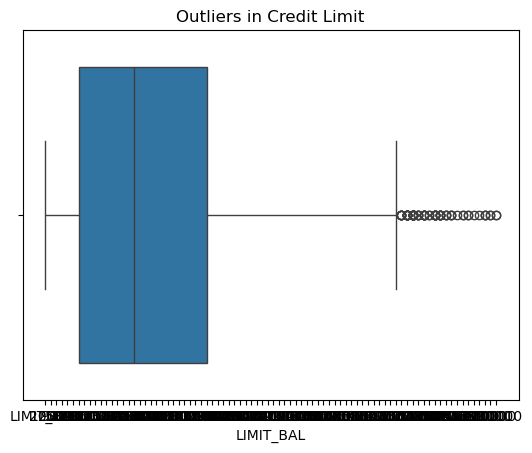

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot for credit limit
sns.boxplot(x=df['LIMIT_BAL'])
plt.title("Outliers in Credit Limit")


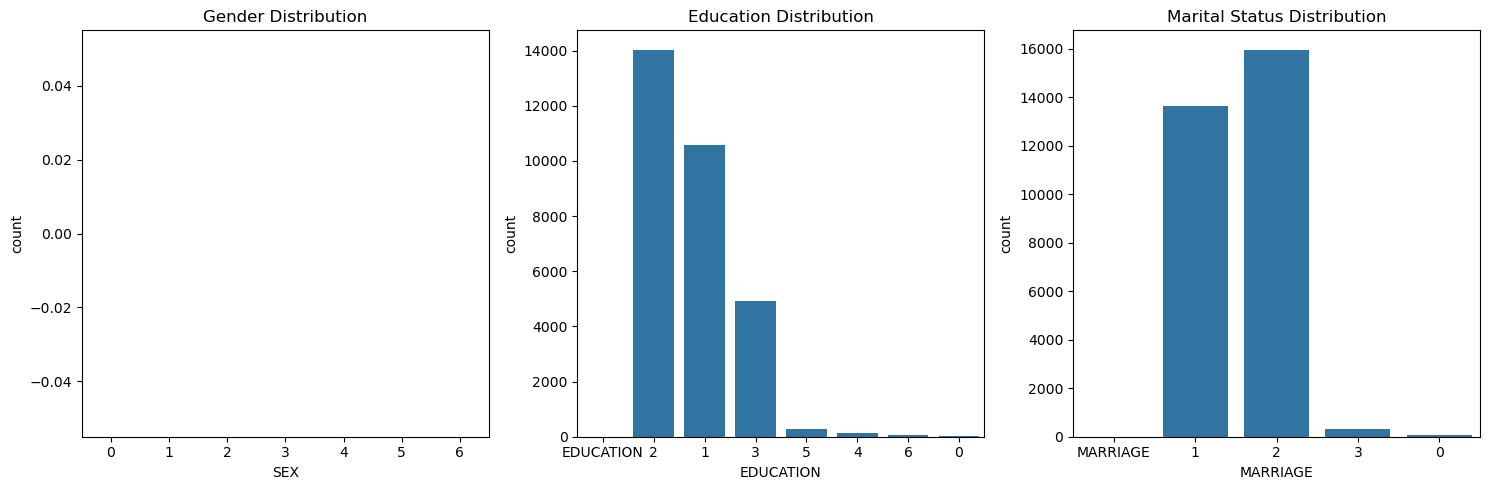

In [24]:
# Rename target column for simplicity
df.rename(columns={'default payment next month': 'default'}, inplace=True)

# Summary statistics
df.describe(include='all')

# Distribution of categorical variables
fig, axes = plt.subplots(1, 3, figsize=(15,5))

sns.countplot(x='SEX', data=df, ax=axes[0])
axes[0].set_title("Gender Distribution")

sns.countplot(x='EDUCATION', data=df, ax=axes[1])
axes[1].set_title("Education Distribution")

sns.countplot(x='MARRIAGE', data=df, ax=axes[2])
axes[2].set_title("Marital Status Distribution")

plt.tight_layout()
plt.show()


#### Target Distributions-EDA

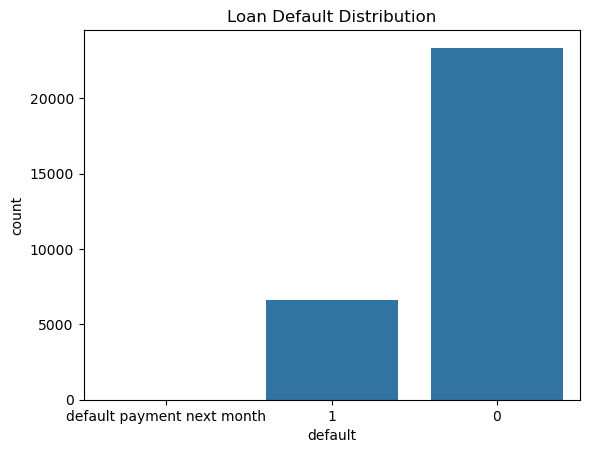

default
0                             77.877404
1                             22.119263
default payment next month     0.003333
Name: proportion, dtype: float64


In [25]:
# Target distribution
sns.countplot(x='default', data=df)
plt.title("Loan Default Distribution")
plt.show()

# Percentage
default_rate = df['default'].value_counts(normalize=True) * 100
print(default_rate)


#### EDA

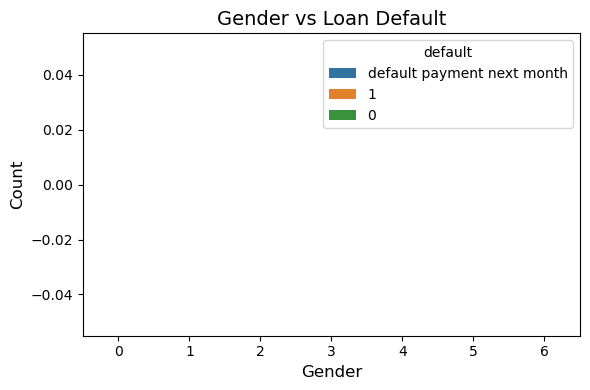

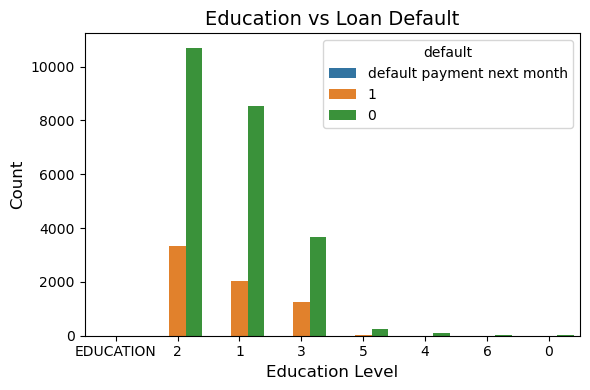

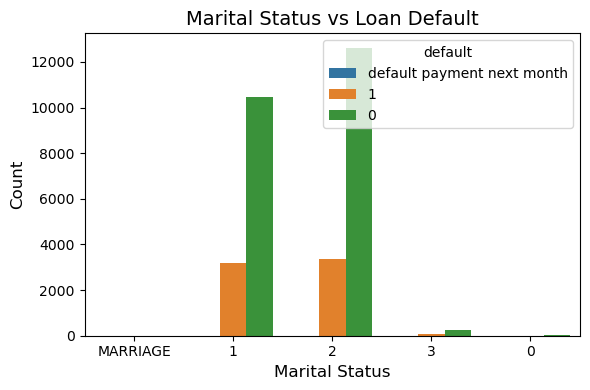

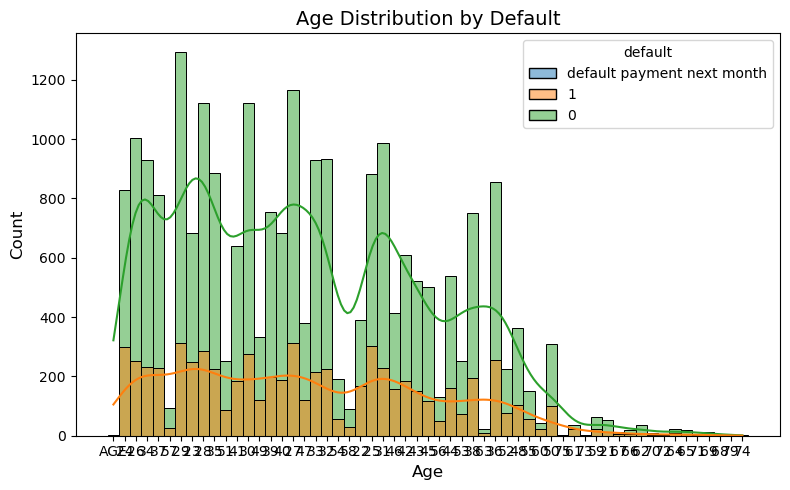

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Gender vs Default
plt.figure(figsize=(6,4))
sns.countplot(x='SEX', hue='default', data=df)
plt.title("Gender vs Loan Default", fontsize=14)
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()

# Education vs Default
plt.figure(figsize=(6,4))
sns.countplot(x='EDUCATION', hue='default', data=df)
plt.title("Education vs Loan Default", fontsize=14)
plt.xlabel("Education Level", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()

# Marital Status vs Default
plt.figure(figsize=(6,4))
sns.countplot(x='MARRIAGE', hue='default', data=df)
plt.title("Marital Status vs Loan Default", fontsize=14)
plt.xlabel("Marital Status", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()

# Age distribution
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='AGE', hue='default', kde=True, bins=30)
plt.title("Age Distribution by Default", fontsize=14)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()


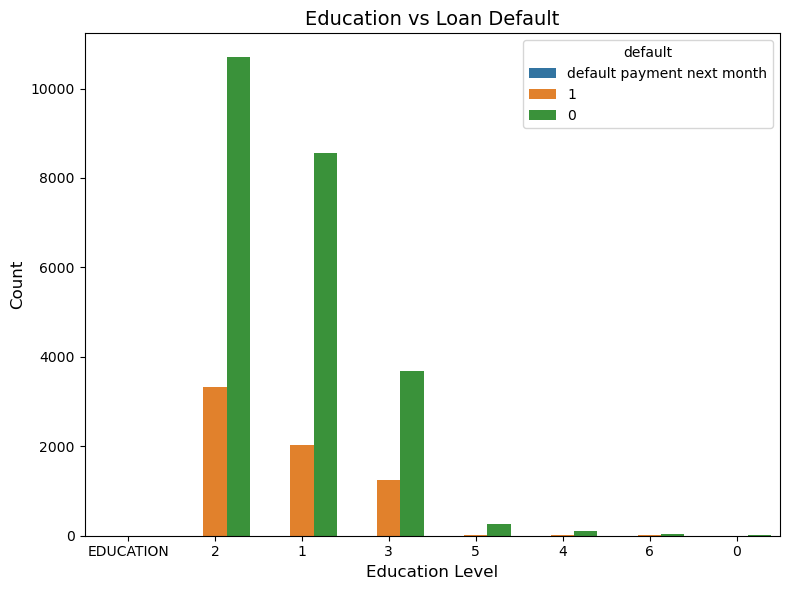

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Example: Education vs Default
plt.figure(figsize=(8,6))  # Increase figure size
sns.countplot(x='EDUCATION', hue='default', data=df)

plt.title("Education vs Loan Default", fontsize=14)
plt.xlabel("Education Level", fontsize=12)
plt.ylabel("Count", fontsize=12)

# Rotate x-axis labels if needed
plt.xticks(rotation=0, fontsize=10)

# Adjust layout so labels fit
plt.tight_layout()
plt.show()


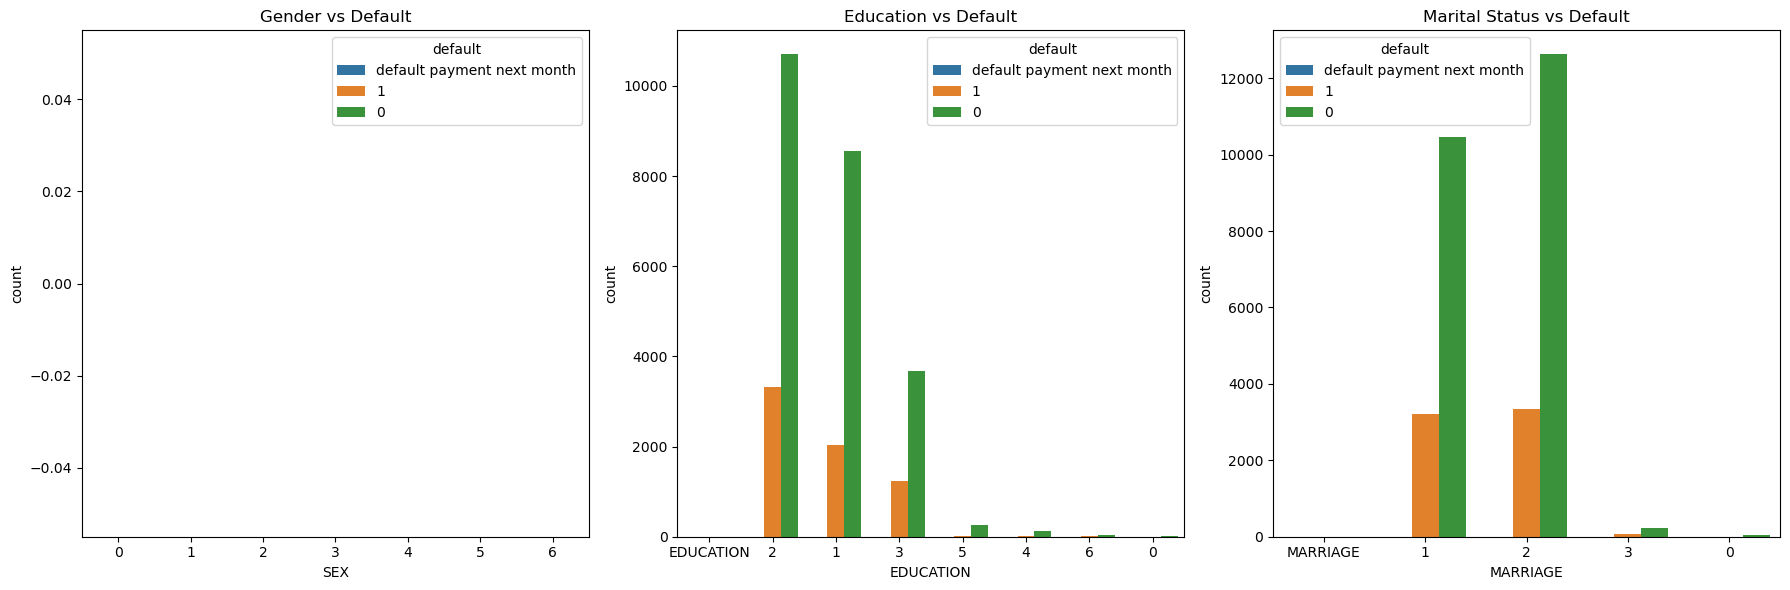

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18,6))

sns.countplot(x='SEX', hue='default', data=df, ax=axes[0])
axes[0].set_title("Gender vs Default")
axes[0].tick_params(axis='x', rotation=0)

sns.countplot(x='EDUCATION', hue='default', data=df, ax=axes[1])
axes[1].set_title("Education vs Default")
axes[1].tick_params(axis='x', rotation=0)

sns.countplot(x='MARRIAGE', hue='default', data=df, ax=axes[2])
axes[2].set_title("Marital Status vs Default")
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


##### Credit Limit Analysis

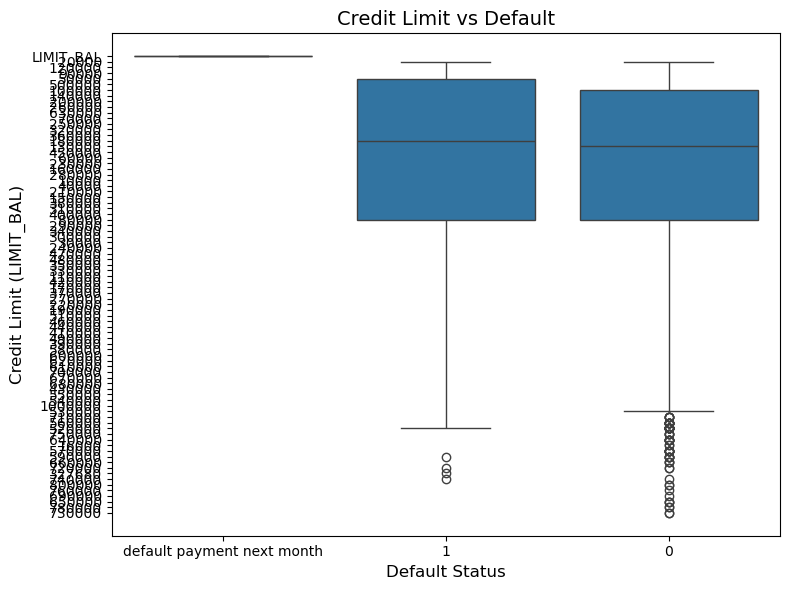

In [29]:
plt.figure(figsize=(8,6))  # make the plot larger
sns.boxplot(x='default', y='LIMIT_BAL', data=df)

plt.title("Credit Limit vs Default", fontsize=14)
plt.xlabel("Default Status", fontsize=12)
plt.ylabel("Credit Limit (LIMIT_BAL)", fontsize=12)

plt.tight_layout()  # ensures labels fit properly
plt.show()



##### Credit Report

In [30]:
# Correct payment status columns
pay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']

# Check the first few rows to confirm they are numeric
print(df[pay_cols].head())



0  PAY_0  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6
0  PAY_0  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6
1      2      2     -1     -1     -2     -2
2     -1      2      0      0      0      2
3      0      0      0      0      0      0
4      0      0      0      0      0      0


In [31]:
# Check data types of PAY_X columns
pay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
print(df[pay_cols].dtypes)


0
PAY_0    object
PAY_2    object
PAY_3    object
PAY_4    object
PAY_5    object
PAY_6    object
dtype: object


In [32]:
# Convert to numeric, coerce errors to NaN
for col in pay_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')



In [33]:
print(df[pay_cols].dtypes)


0
PAY_0    float64
PAY_2    float64
PAY_3    float64
PAY_4    float64
PAY_5    float64
PAY_6    float64
dtype: object


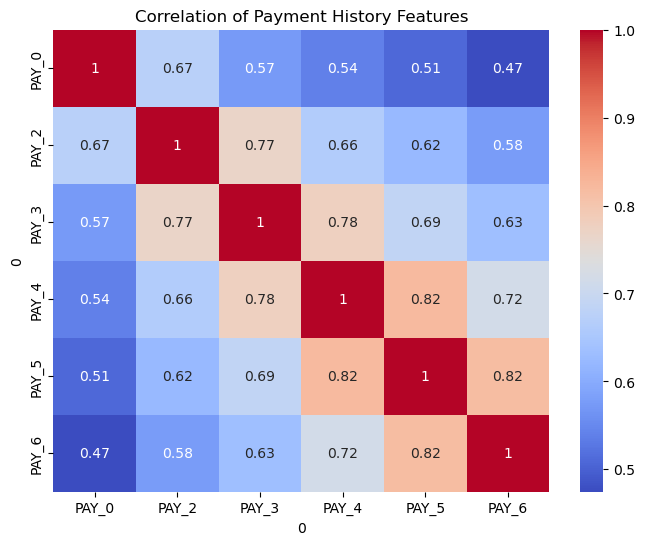

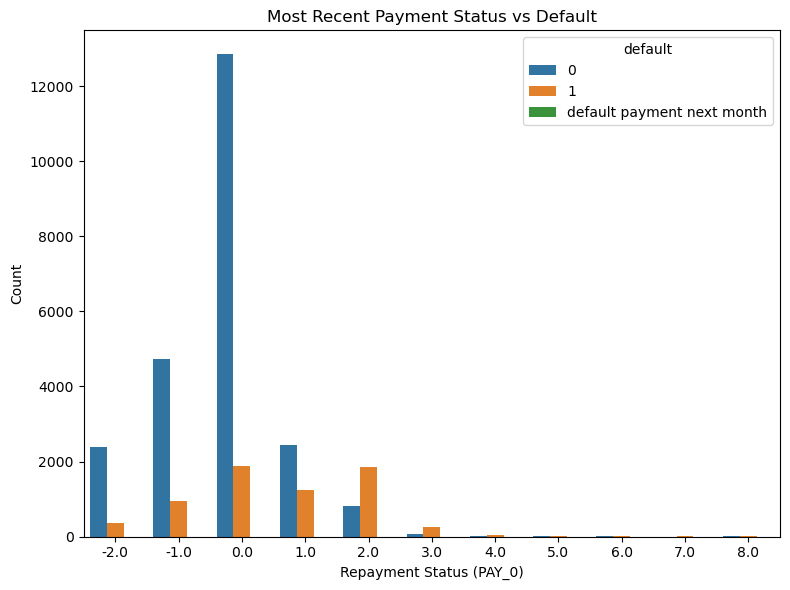

In [34]:
# Correlation heatmap (numeric values only)
plt.figure(figsize=(8,6))
sns.heatmap(df[pay_cols].astype(float).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation of Payment History Features")
plt.show()

# Default vs most recent payment status
plt.figure(figsize=(8,6))
sns.countplot(x='PAY_0', hue='default', data=df)
plt.title("Most Recent Payment Status vs Default")
plt.xlabel("Repayment Status (PAY_0)")
plt.ylabel("Count")
plt.tight_layout()

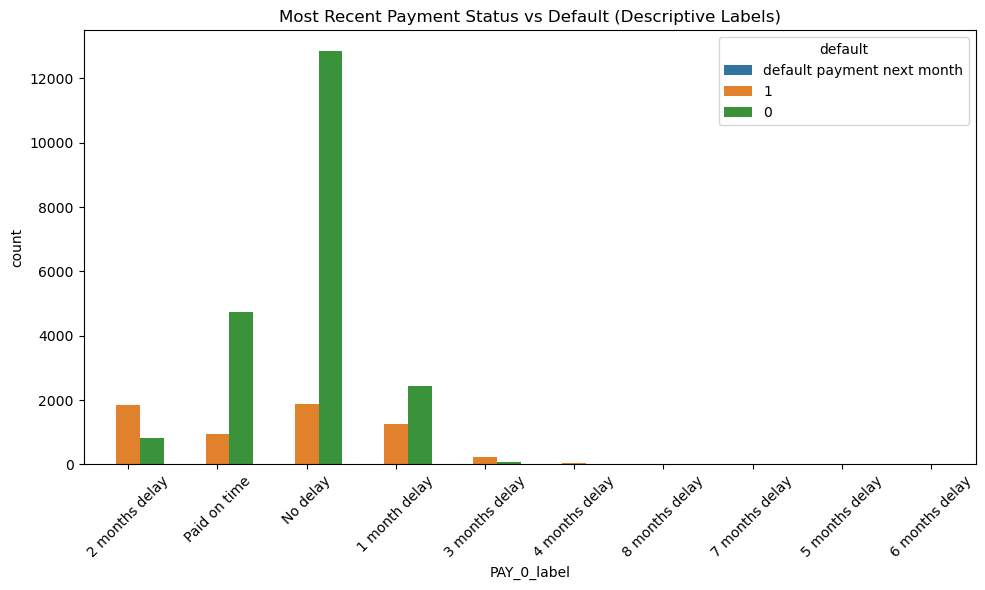

In [35]:
status_map = {
    -1: "Paid on time",
     0: "No delay",
     1: "1 month delay",
     2: "2 months delay",
     3: "3 months delay",
     4: "4 months delay",
     5: "5 months delay",
     6: "6 months delay",
     7: "7 months delay",
     8: "8 months delay",
     9: "9+ months delay"
}

df['PAY_0_label'] = df['PAY_0'].map(status_map)

plt.figure(figsize=(10,6))
sns.countplot(x='PAY_0_label', hue='default', data=df)
plt.xticks(rotation=45)
plt.title("Most Recent Payment Status vs Default (Descriptive Labels)")
plt.tight_layout()
plt.show()


##### Data Processing

In [36]:
#definbe features and targets
x=df.drop(columns=["default"])
y=df["default"]

In [37]:
# Convert to numeric, coerce errors to NaN
df['default'] = pd.to_numeric(df['default'], errors='coerce')


In [38]:
# Drop rows where target is NaN (the stray string row)
df = df.dropna(subset=['default'])


In [39]:
print(df['default'].value_counts())

default
0.0    23364
1.0     6636
Name: count, dtype: int64


In [41]:
X = df.drop(columns=["default"])
y=df["default"]

In [42]:
# to Keep only rows where target is 0 or 1
df = df[df['default'].isin([0,1])]

In [43]:
# Now X and y
X = df.drop('default', axis=1)
y = df['default']

In [44]:
# Confirm lengths match
print(len(X), len(y))


30000 30000


In [45]:
# Convert features to numeric safely
X = X.apply(pd.to_numeric, errors='coerce')

# Align target with cleaned features
y = y.loc[X.index]

print("Dataset size:", X.shape, y.shape)

Dataset size: (30000, 25) (30000,)


In [46]:
# Convert all features to numeric, coerce errors to NaN
X = df.drop('default', axis=1).apply(pd.to_numeric, errors='coerce')

# Drop rows with NaN 
df = df.loc[X.index]   # keep consistent rows
X = X.dropna()
y = df.loc[X.index, 'default']


In [47]:
df=pd.read_csv(r"C:\Users\MSI\Downloads\default of credit card clients sk.csv")
df.shape
df.columns

Index(['Unnamed: 0', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9',
       'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19',
       'X20', 'X21', 'X22', 'X23', 'Y'],
      dtype='object')

In [48]:
df.shape

(30001, 25)

In [49]:
df.columns=df.iloc[0]

In [50]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object', name=0)

In [51]:
# Drop the first row (index 0)
df = df.drop(index=0).reset_index(drop=True)

In [52]:
df.shape

(30000, 25)

In [53]:
df.rename(columns={'default payment next month':'default'}, inplace=True)


In [54]:
pay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
print(df[pay_cols].head())

0 PAY_0 PAY_2 PAY_3 PAY_4 PAY_5 PAY_6
0     2     2    -1    -1    -2    -2
1    -1     2     0     0     0     2
2     0     0     0     0     0     0
3     0     0     0     0     0     0
4    -1     0    -1     0     0     0


In [55]:
df[pay_cols] = df[pay_cols].apply(pd.to_numeric, errors='coerce')


In [56]:
X = df.drop('default', axis=1)
y = df['default']

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

###### Validating the Train model before Testing

In [57]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(24000, 24) (24000,)
(6000, 24) (6000,)


In [58]:
print(X_train.isnull().sum().sort_values(ascending=False).head())

0
ID           0
LIMIT_BAL    0
PAY_AMT5     0
PAY_AMT4     0
PAY_AMT3     0
dtype: int64


In [59]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [60]:
print(X_train.isnull().sum().sum())  # total missing values in features
print(y_train.isnull().sum())        # missing values in target


0
0


In [61]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

log_reg = LogisticRegression(max_iter=1000, class_weight='balanced')


In [62]:
scores_acc = cross_val_score(log_reg, X_train_scaled, y_train, cv=cv, scoring='accuracy')
scores_auc = cross_val_score(log_reg, X_train_scaled, y_train, cv=cv, scoring='roc_auc')

print("Accuracy scores:", scores_acc)
print("Mean Accuracy:", scores_acc.mean())
print("ROC‑AUC scores:", scores_auc)
print("Mean ROC‑AUC:", scores_auc.mean())

Accuracy scores: [0.69125    0.69625    0.67604167 0.68520833 0.7075    ]
Mean Accuracy: 0.6912499999999999
ROC‑AUC scores: [0.74137621 0.72780115 0.71088198 0.71923312 0.73318259]
Mean ROC‑AUC: 0.7264950119915865


##### Training the model to know whichone is perfoming better

In [63]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score

# Logistic Regression (already done)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)


In [64]:
# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


In [65]:
# Gradient Boosting
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)


###### MODEL Evaluation

In [68]:
# Convert target column to integers
y_train = y_train.astype(int)
y_test = y_test.astype(int)


In [70]:
# Convert predictions to integers
y_pred_lr = y_pred_lr.astype(int)
y_pred_rf = y_pred_rf.astype(int)
y_pred_gb = y_pred_gb.astype(int)


In [71]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

results = {
    "Logistic Regression": {
        "Accuracy": accuracy_score(y_test, y_pred_lr),
        "F1": f1_score(y_test, y_pred_lr, pos_label=1),
        "ROC-AUC": roc_auc_score(y_test, log_reg.predict_proba(X_test_scaled)[:,1])
    },
    "Random Forest": {
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "F1": f1_score(y_test, y_pred_rf, pos_label=1),
        "ROC-AUC": roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])
    },
    "Gradient Boosting": {
        "Accuracy": accuracy_score(y_test, y_pred_gb),
        "F1": f1_score(y_test, y_pred_gb, pos_label=1),
        "ROC-AUC": roc_auc_score(y_test, gb.predict_proba(X_test)[:,1])
    }
}

for model, metrics in results.items():
    print(f"\n{model}")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.3f}")



Logistic Regression
Accuracy: 0.681
F1: 0.463
ROC-AUC: 0.708

Random Forest
Accuracy: 0.813
F1: 0.442
ROC-AUC: 0.765

Gradient Boosting
Accuracy: 0.819
F1: 0.471
ROC-AUC: 0.779


##### Hypertuning Gradient Boosting

In [72]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0]
}


In [ ]:
gb = GradientBoostingClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    scoring='f1',   # optimize for F1 since defaults are minority class
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best F1 Score:", grid_search.best_score_)


Fitting 5 folds for each of 54 candidates, totalling 270 fits


##### Evaluation of Tune Test Gradient

In [76]:
best_gb = grid_search.best_estimator_
y_pred_best = best_gb.predict(X_test)

print("Tuned Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_best))
print("Tuned Gradient Boosting F1:", f1_score(y_test, y_pred_best))
print("Tuned Gradient Boosting ROC-AUC:", roc_auc_score(y_test, best_gb.predict_proba(X_test)[:,1]))


Tuned Gradient Boosting Accuracy: 0.8156666666666667
Tuned Gradient Boosting F1: 0.46570048309178746
Tuned Gradient Boosting ROC-AUC: 0.7783970704415415
